In [20]:
!pip install wfdb

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from collections import Counter
import re
import wfdb

In [22]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    url,
    names=columns,
    na_values="?"
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [23]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (303, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [24]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [25]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [26]:
categorical_columns = [
    "ca",
    "thal"
]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [27]:
df["target"] = (df["target"] > 0).astype(int)

df["target"].value_counts()

,count
target,
0,164
1,139


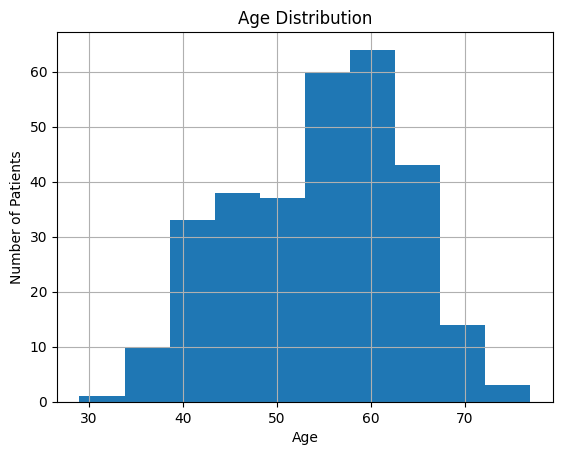

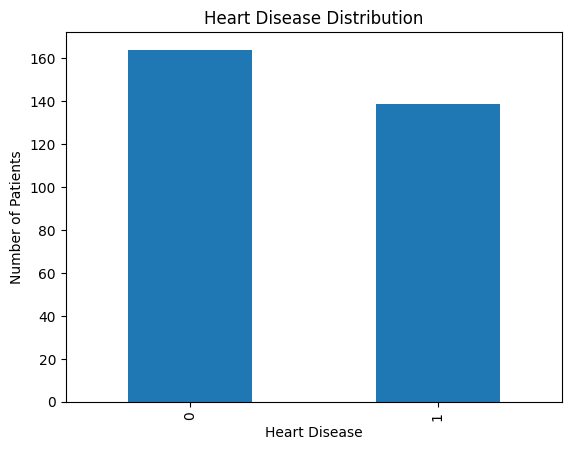

In [28]:
df["age"].hist()

plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")
plt.show()

df["target"].value_counts().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Distribution")
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

X = df.drop("target", axis=1)
y = df["target"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [33]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [34]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("Sampling frequency:", record.fs)
print("Number of samples:", record.sig_len)
print("Number of channels:", record.n_sig)
print("Signal names:", record.sig_name)

Sampling frequency: 360
Number of samples: 650000
Number of channels: 2
Signal names: ['MLII', 'V5']


In [35]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

print("Sampling frequency:", record.fs)
print("Number of samples:", record.sig_len)
print("Number of channels:", record.n_sig)
print("Signal names:", record.sig_name)

Sampling frequency: 360
Number of samples: 650000
Number of channels: 2
Signal names: ['MLII', 'V5']


In [36]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("Annotation symbols:")
print(annotation.symbol[:20])

print("\nAnnotation samples:")
print(annotation.sample[:20])

Annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']

Annotation samples:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


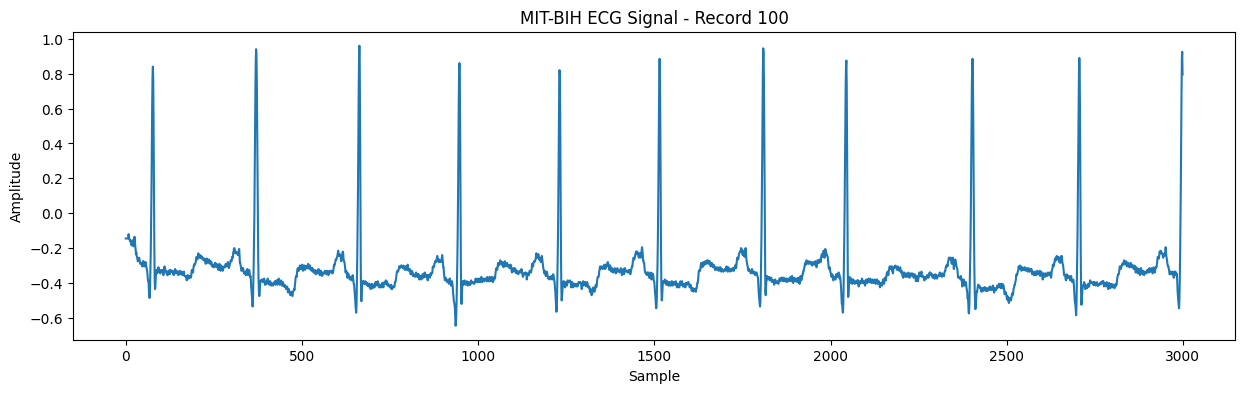

In [37]:
signal = record.p_signal[:, 0]

plt.figure(figsize=(15, 4))

plt.plot(signal[:3000])

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("MIT-BIH ECG Signal - Record 100")

plt.show()

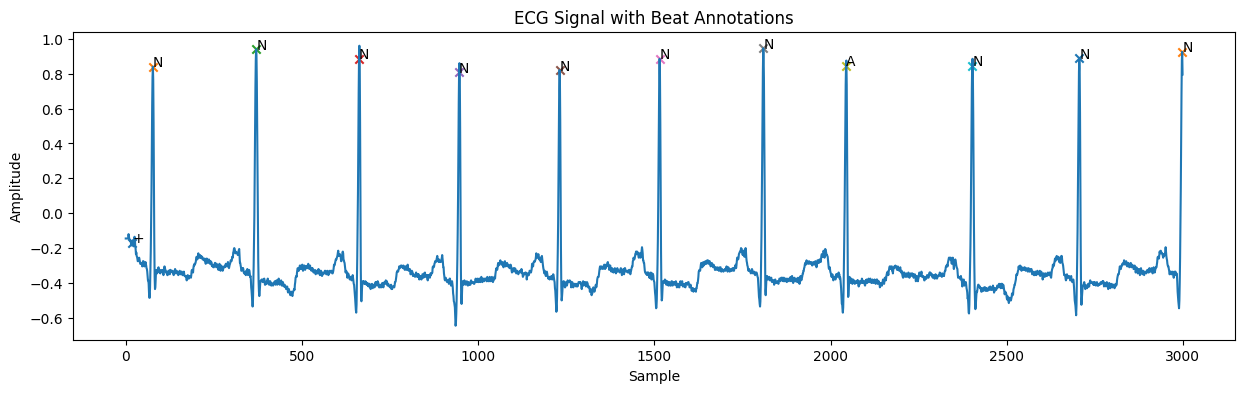

In [38]:
annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)
samples = annotation.sample
symbols = annotation.symbol

plt.figure(figsize=(15, 4))

plt.plot(signal[:3000])

for sample, symbol in zip(samples, symbols):
    if sample < 3000:
        plt.scatter(sample, signal[sample], marker="x")
        plt.text(sample, signal[sample], symbol)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("ECG Signal with Beat Annotations")

plt.show()

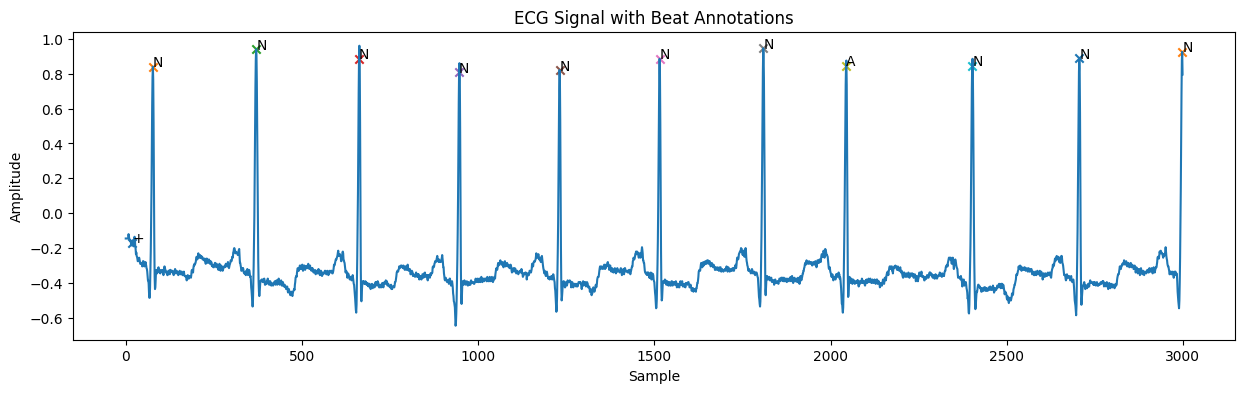

In [39]:
samples = annotation.sample
symbols = annotation.symbol

plt.figure(figsize=(15, 4))

plt.plot(signal[:3000])

for sample, symbol in zip(samples, symbols):
    if sample < 3000:
        plt.scatter(sample, signal[sample], marker="x")
        plt.text(sample, signal[sample], symbol)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("ECG Signal with Beat Annotations")

plt.show()

In [40]:
r_peaks = annotation.sample

rr_intervals = np.diff(r_peaks) / record.fs

print("First 10 RR intervals:")
print(rr_intervals[:10])

print("\nAverage RR interval:",
      np.mean(rr_intervals),
      "seconds")

First 10 RR intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]

Average RR interval: 0.7943161265092633 seconds


In [41]:
r_peaks = annotation.sample

rr_intervals = np.diff(r_peaks) / record.fs

print("First 10 RR intervals:")
print(rr_intervals[:10])

print("\nAverage RR interval:",
      np.mean(rr_intervals),
      "seconds")

First 10 RR intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]

Average RR interval: 0.7943161265092633 seconds


In [42]:
clinical_note = """
The patient is a 58 year old male presenting with chest pain
and shortness of breath during physical activity. The patient
has a history of hypertension and elevated cholesterol.
Heart rate is 92 beats per minute. The patient reports occasional
fatigue and discomfort in the chest.
"""

print(clinical_note)


The patient is a 58 year old male presenting with chest pain
and shortness of breath during physical activity. The patient
has a history of hypertension and elevated cholesterol.
Heart rate is 92 beats per minute. The patient reports occasional
fatigue and discomfort in the chest.



In [43]:
text = clinical_note.lower()

text = re.sub(r'[^a-z\s]', '', text)

words = text.split()

print(words)
word_frequency = Counter(words)

print(word_frequency)

['the', 'patient', 'is', 'a', 'year', 'old', 'male', 'presenting', 'with', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'during', 'physical', 'activity', 'the', 'patient', 'has', 'a', 'history', 'of', 'hypertension', 'and', 'elevated', 'cholesterol', 'heart', 'rate', 'is', 'beats', 'per', 'minute', 'the', 'patient', 'reports', 'occasional', 'fatigue', 'and', 'discomfort', 'in', 'the', 'chest']
Counter({'the': 4, 'patient': 3, 'and': 3, 'is': 2, 'a': 2, 'chest': 2, 'of': 2, 'year': 1, 'old': 1, 'male': 1, 'presenting': 1, 'with': 1, 'pain': 1, 'shortness': 1, 'breath': 1, 'during': 1, 'physical': 1, 'activity': 1, 'has': 1, 'history': 1, 'hypertension': 1, 'elevated': 1, 'cholesterol': 1, 'heart': 1, 'rate': 1, 'beats': 1, 'per': 1, 'minute': 1, 'reports': 1, 'occasional': 1, 'fatigue': 1, 'discomfort': 1, 'in': 1})


In [44]:
word_frequency = Counter(words)

print(word_frequency)

Counter({'the': 4, 'patient': 3, 'and': 3, 'is': 2, 'a': 2, 'chest': 2, 'of': 2, 'year': 1, 'old': 1, 'male': 1, 'presenting': 1, 'with': 1, 'pain': 1, 'shortness': 1, 'breath': 1, 'during': 1, 'physical': 1, 'activity': 1, 'has': 1, 'history': 1, 'hypertension': 1, 'elevated': 1, 'cholesterol': 1, 'heart': 1, 'rate': 1, 'beats': 1, 'per': 1, 'minute': 1, 'reports': 1, 'occasional': 1, 'fatigue': 1, 'discomfort': 1, 'in': 1})


In [45]:
print(word_frequency.most_common(10))

[('the', 4), ('patient', 3), ('and', 3), ('is', 2), ('a', 2), ('chest', 2), ('of', 2), ('year', 1), ('old', 1), ('male', 1)]


In [46]:
medical_terms = [
    "chest pain",
    "shortness of breath",
    "hypertension",
    "cholesterol",
    "fatigue"
]

for term in medical_terms:
    if term in clinical_note.lower():
        print("Found:", term)

Found: chest pain
Found: shortness of breath
Found: hypertension
Found: cholesterol
Found: fatigue


In [52]:
clinical_note

'\nThe patient is a 58 year old male presenting with chest pain\nand shortness of breath during physical activity. The patient\nhas a history of hypertension and elevated cholesterol.\nHeart rate is 92 beats per minute. The patient reports occasional\nfatigue and discomfort in the chest.\n'